# Model 2 — Advanced CNN for Malaria Diagnosis


This notebook implements the second model in the group's malaria diagnosis pipeline.  
It builds upon the baseline CNN (Model 1) by introducing:
- **Data Augmentation** — random flips, rotations, and zooms to improve generalization
- **Deeper Convolutional Blocks** — 3 stacked Conv layers instead of 1–2
- **Batch Normalization** — stabilizes training and reduces internal covariate shift
- **Dropout Regularization** — reduces overfitting by randomly disabling neurons during training

Seven experiments are conducted by systematically varying augmentation, depth, dropout rate, learning rate, and optimizer.

## 1. Environment Setup

In [1]:
# Mount Google Drive (optional — only needed if saving checkpoints to Drive)
# from google.colab import drive
# drive.mount('/content/drive/')

# Confirm GPU is available — should print /device:GPU:0
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU device:", tf.test.gpu_device_name())

TensorFlow version: 2.20.0
GPU device: /device:GPU:0


## 2. Import Libraries



In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, RMSprop

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

The NIH malaria cell images dataset is downloaded from the official source.
It contains 27,560 images split equally between two classes:
- **Parasitized** — cells infected with the malaria parasite
- **Uninfected** — healthy cells

In [3]:
# Download the dataset from NIH
# Skip this cell if cell_images/ folder already exists
import os

if not os.path.exists('cell_images'):
    print("Downloading dataset...")
    !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip -q cell_images.zip
    print("Done.")
else:
    print("Dataset already exists, skipping download.")

# Confirm class counts
parasitized = len(os.listdir('cell_images/Parasitized'))
uninfected  = len(os.listdir('cell_images/Uninfected'))
print(f"Parasitized images: {parasitized}")
print(f"Uninfected images:  {uninfected}")

Done.
Parasitized images: 13780
Uninfected images:  13780


In [4]:
# ── Default datasets (batch=32, image_size=128x128) ──────────────────────────
# These are used by most experiments unless a specific batch size is needed.

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

# Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Classes: ['Parasitized', 'Uninfected']


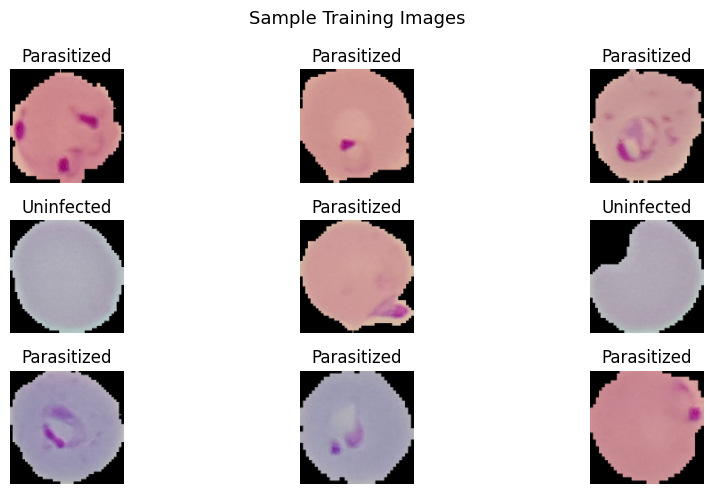

In [5]:
# Visualise a sample of training images to confirm data loaded correctly
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis('off')
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Model Architecture

### Design Rationale

The advanced CNN is designed around three key improvements over the baseline:

1. **Data Augmentation Layer** (inside the model)

2. **Three Convolutional Blocks**

3. **Batch Normalization**

4. **Dropout (0.5)**

In [6]:
def build_advanced_model(
    use_augmentation=True,
    num_filters=[32, 64, 128],
    dropout_rate=0.5,
    dense_units=256,
    learning_rate=1e-3,
    optimizer_name="adam"
):
    """
    Builds an advanced CNN for binary malaria classification.

    Parameters
    ----------
    use_augmentation : bool   — whether to include the augmentation layer
    num_filters      : list   — number of filters per conv block
    dropout_rate     : float  — dropout fraction before the output layer
    dense_units      : int    — number of units in the fully-connected layer
    learning_rate    : float  — optimizer learning rate
    optimizer_name   : str    — 'adam' or 'rmsprop'
    """
    inputs = tf.keras.Input(shape=(128, 128, 3))

    # ── Pixel normalisation (0–255 → 0–1) ────────────────────────────────────
    x = layers.Rescaling(1.0 / 255)(inputs)

    # ── Optional data augmentation (only active during training) ─────────────
    if use_augmentation:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)

    # ── Convolutional blocks ──────────────────────────────────────────────────
    for filters in num_filters:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2, 2)(x)

    # ── Classification head ───────────────────────────────────────────────────
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    # ── Optimizer selection ───────────────────────────────────────────────────
    opt = Adam(learning_rate=learning_rate) if optimizer_name == "adam" \
          else RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Print architecture summary for the default model
build_advanced_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,265 (32.36 MB)

 Trainable params: 8,482,817 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Evaluation Helper Functions

These reusable functions compute metrics and produce all required visualisations:
learning curves, confusion matrix, and ROC/AUC curve.

In [7]:
def evaluate_model(model, dataset):
    """
    Run inference on a dataset and return true labels,
    predicted labels, and raw prediction scores.
    """
    y_true, y_pred, y_scores = [], [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_scores.extend(preds.flatten())
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES))
    return np.array(y_true), np.array(y_pred), np.array(y_scores)


def plot_learning_curves(history, title="Learning Curves"):
    """Plot training vs validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     fontsize=14, color='black')
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_scores, title="ROC Curve"):
    """Plot ROC curve and print AUC score."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"AUC: {roc_auc:.4f}")
    return roc_auc


print("Helper functions defined successfully.")

Helper functions defined successfully.


## 6. Experiments

Seven experiments are conducted. Each experiment changes **one variable** while keeping everything else constant

| Experiment | What Changes | Purpose |
|---|---|---|
| E1 | Default advanced model | Establish the advanced baseline |
| E2 | No data augmentation | Measure augmentation's impact |
| E3 | 2 conv blocks instead of 3 | Test effect of shallower depth |
| E4 | 4 conv blocks | Test effect of greater depth |
| E5 | Dropout = 0.6 | Stronger regularization |
| E6 | Learning rate = 1e-4 | Finer weight updates |
| E7 | RMSprop optimizer | Alternative adaptive optimizer |

### Experiment 1 — Default Advanced CNN


 Experiment 1 — Default Advanced CNN
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.6331 - loss: 0.8011 - val_accuracy: 0.5745 - val_loss: 1.4702
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.8564 - loss: 0.3408 - val_accuracy: 0.9325 - val_loss: 0.1799
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9203 - loss: 0.2252 - val_accuracy: 0.9526 - val_loss: 0.1528
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.9348 - loss: 0.2123 - val_accuracy: 0.9503 - val_loss: 0.1704
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9382 - loss: 0.2006 - val_accuracy: 0.9354 - val_loss: 0.1781
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.9424 - loss: 0.1836 - val_accuracy: 0.8427 - val_loss: 0.3332
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9403 - loss: 0.1907 - val_accuracy: 0.9528 - val_loss: 0.1484
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step

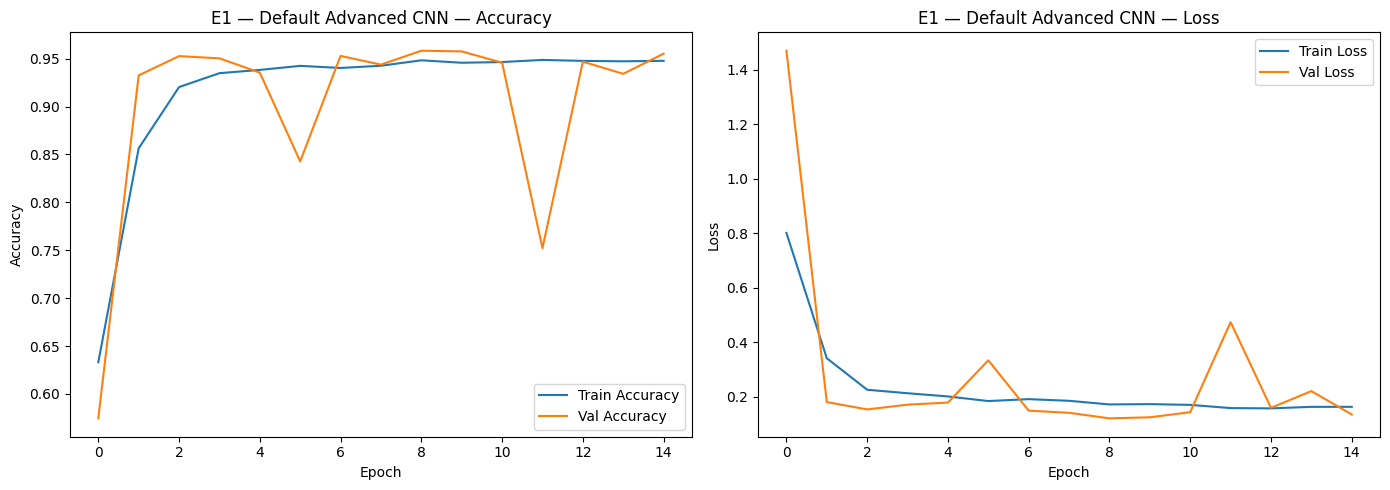

In [8]:
print("=" * 55)
print(" Experiment 1 — Default Advanced CNN")
print("=" * 55)

adv_model_e1 = build_advanced_model(
    use_augmentation=True,
    num_filters=[32, 64, 128],
    dropout_rate=0.5,
    dense_units=256,
    learning_rate=1e-3,
    optimizer_name="adam"
)

hist_adv1 = adv_model_e1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv1, title="E1 — Default Advanced CNN")

### Experiment 2 — No Data Augmentation


 Experiment 2 — No Data Augmentation
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.6810 - loss: 0.7113 - val_accuracy: 0.8626 - val_loss: 0.3225
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8973 - loss: 0.2807 - val_accuracy: 0.9363 - val_loss: 0.1722
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9307 - loss: 0.2216 - val_accuracy: 0.9418 - val_loss: 0.1619
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9387 - loss: 0.2036 - val_accuracy: 0.9563 - val_loss: 0.1367
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9430 - loss: 0.1869 - val_accuracy: 0.5026 - val_loss: 4.1961
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9433 - loss: 0.1763 - val_accuracy: 0.9425 - val_loss: 0.1667
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9478 - loss: 0.1615 - val_accuracy: 0.9526 - val_loss: 0.1506
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step

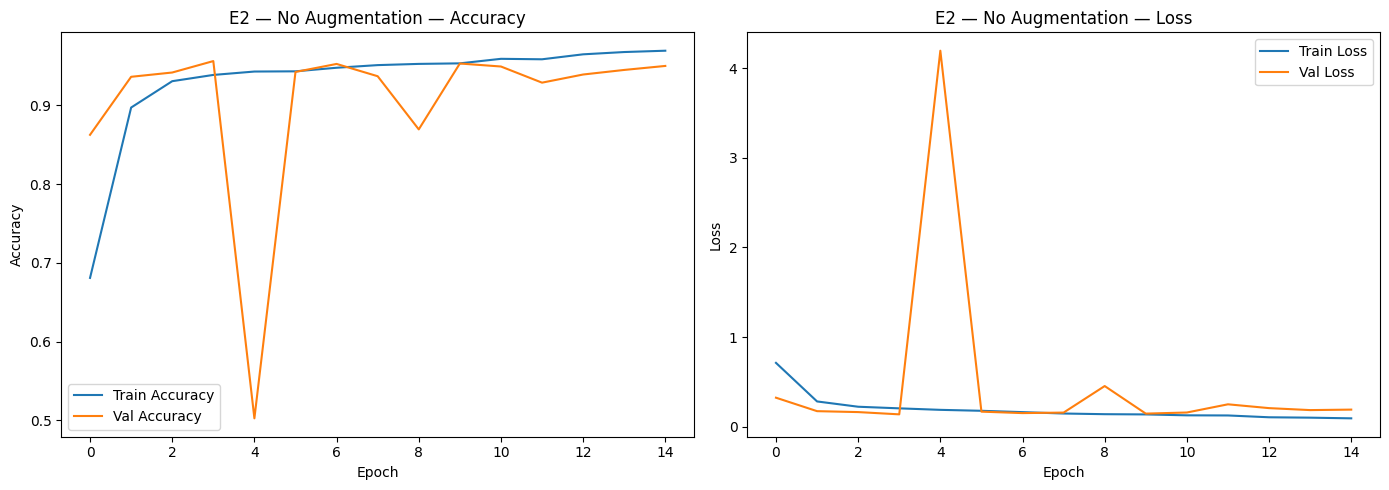

In [9]:
print("=" * 55)
print(" Experiment 2 — No Data Augmentation")
print("=" * 55)

adv_model_e2 = build_advanced_model(use_augmentation=False)

hist_adv2 = adv_model_e2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv2, title="E2 — No Augmentation")

### Experiment 3 — Shallower Network (2 Conv Blocks)


 Experiment 3 — 2 Conv Blocks (Shallower)
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.5890 - loss: 1.1903 - val_accuracy: 0.6698 - val_loss: 0.6557
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.5970 - loss: 0.6821 - val_accuracy: 0.4956 - val_loss: 1.0684
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.6165 - loss: 0.6549 - val_accuracy: 0.6237 - val_loss: 0.6212
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.6421 - loss: 0.5984 - val_accuracy: 0.6552 - val_loss: 0.5562
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.7467 - loss: 0.4824 - val_accuracy: 0.9036 - val_loss: 0.3193
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8517 - loss: 0.3656 - val_accuracy: 0.9011 - val_loss: 0.2356
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.8886 - loss: 0.3104 - val_accuracy: 0.9392 - val_loss: 0.1773
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms

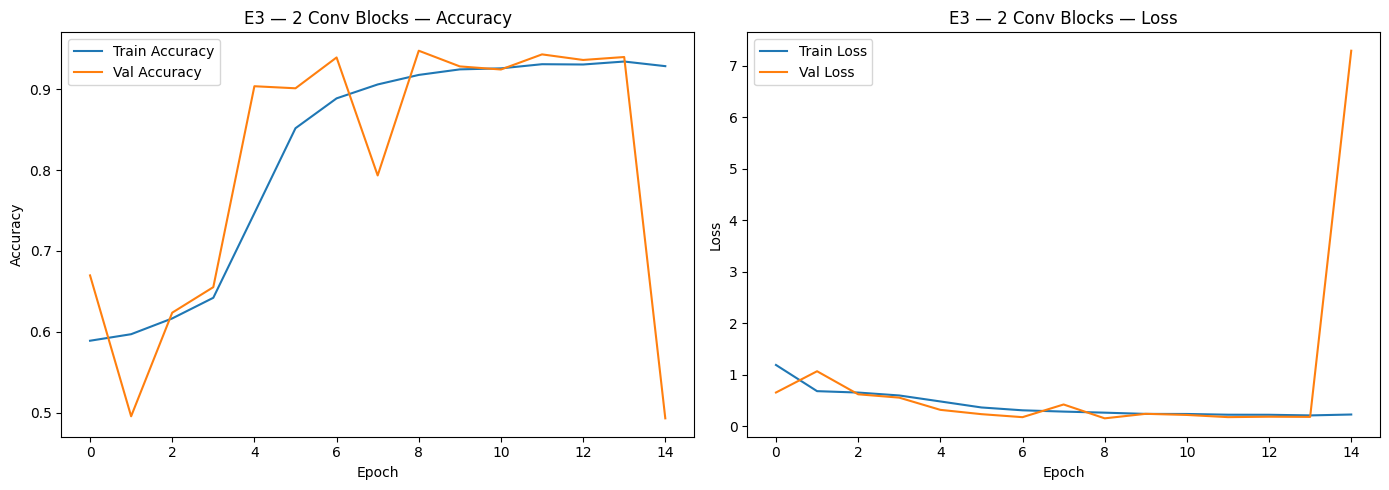

In [10]:
print("=" * 55)
print(" Experiment 3 — 2 Conv Blocks (Shallower)")
print("=" * 55)

adv_model_e3 = build_advanced_model(num_filters=[32, 64])

hist_adv3 = adv_model_e3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv3, title="E3 — 2 Conv Blocks")

### Experiment 4 — Deeper Network (4 Conv Blocks)


 Experiment 4 — 4 Conv Blocks (Deeper)
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.7929 - loss: 0.5983 - val_accuracy: 0.9258 - val_loss: 0.1938
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9392 - loss: 0.1995 - val_accuracy: 0.9047 - val_loss: 0.2440
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9459 - loss: 0.1845 - val_accuracy: 0.9218 - val_loss: 0.1947
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9467 - loss: 0.1729 - val_accuracy: 0.9528 - val_loss: 0.1445
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9505 - loss: 0.1624 - val_accuracy: 0.9552 - val_loss: 0.1401
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9500 - loss: 0.1638 - val_accuracy: 0.9499 - val_loss: 0.1432
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9513 - loss: 0.1591 - val_accuracy: 0.9583 - val_loss: 0.1218
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/st

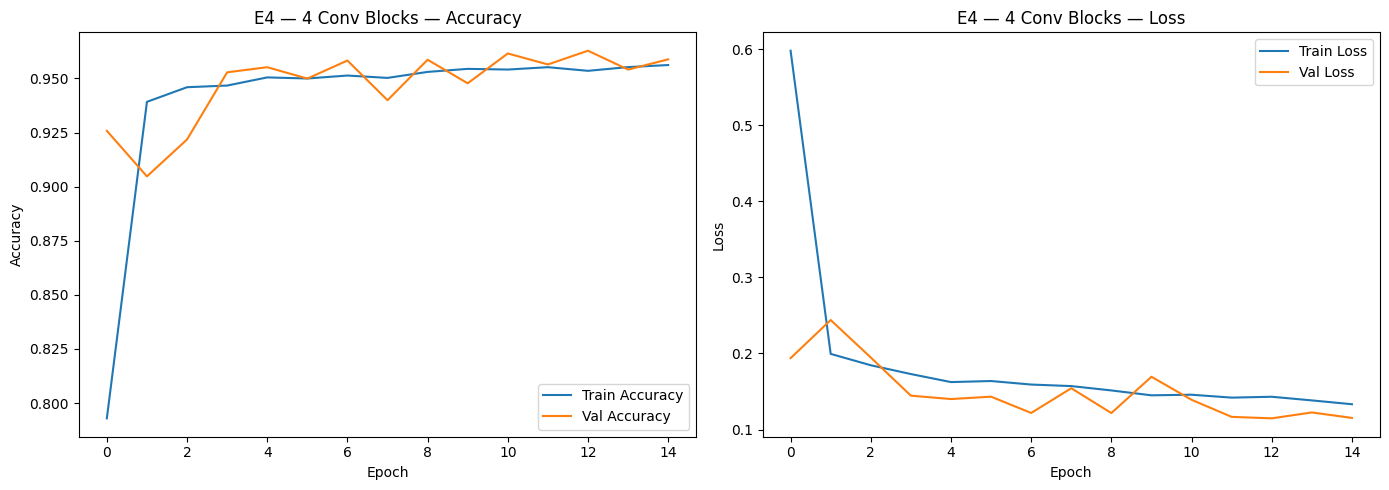

In [11]:
print("=" * 55)
print(" Experiment 4 — 4 Conv Blocks (Deeper)")
print("=" * 55)

adv_model_e4 = build_advanced_model(num_filters=[32, 64, 128, 256])

hist_adv4 = adv_model_e4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv4, title="E4 — 4 Conv Blocks")

### Experiment 5 — Higher Dropout (0.6)



 Experiment 5 — Dropout = 0.6
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.6611 - loss: 0.9517 - val_accuracy: 0.6797 - val_loss: 0.5620
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.8793 - loss: 0.3081 - val_accuracy: 0.9418 - val_loss: 0.1744
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9169 - loss: 0.2599 - val_accuracy: 0.9503 - val_loss: 0.1430
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9306 - loss: 0.2283 - val_accuracy: 0.9537 - val_loss: 0.1377
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9315 - loss: 0.2196 - val_accuracy: 0.9470 - val_loss: 0.1510
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9367 - loss: 0.2078 - val_accuracy: 0.9457 - val_loss: 0.1988
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.9389 - loss: 0.1955 - val_accuracy: 0.8886 - val_loss: 0.2703
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accu

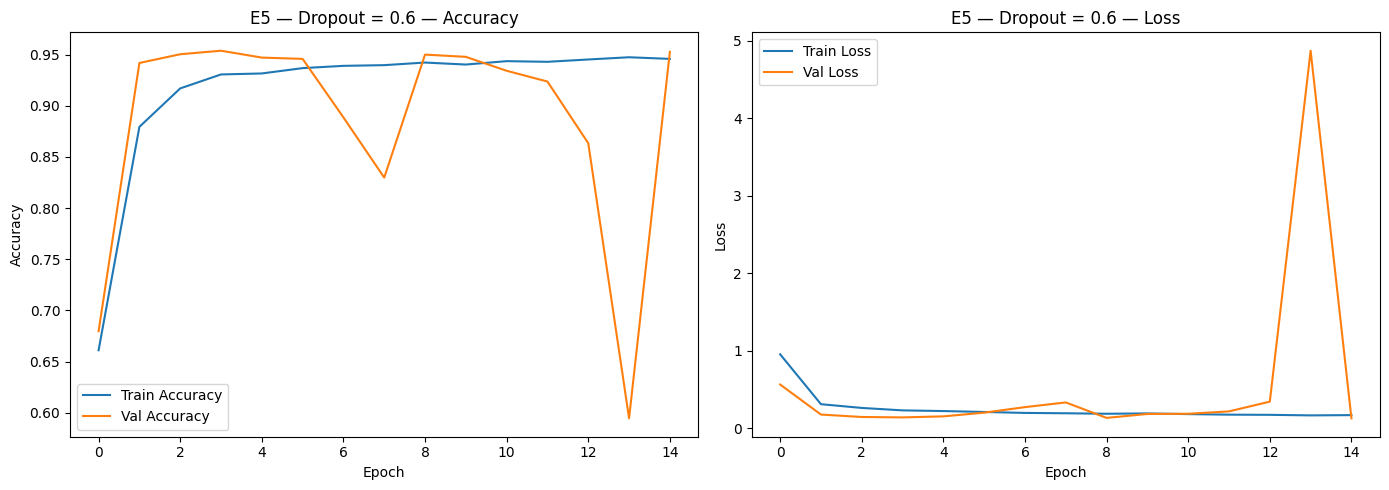

In [12]:
print("=" * 55)
print(" Experiment 5 — Dropout = 0.6")
print("=" * 55)

adv_model_e5 = build_advanced_model(dropout_rate=0.6)

hist_adv5 = adv_model_e5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv5, title="E5 — Dropout = 0.6")

### Experiment 6 — Lower Learning Rate (1e-4)


 Experiment 6 — Learning Rate = 1e-4
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.7941 - loss: 0.4681 - val_accuracy: 0.7572 - val_loss: 0.4516
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.9219 - loss: 0.2159 - val_accuracy: 0.6013 - val_loss: 0.9229
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9389 - loss: 0.1857 - val_accuracy: 0.9376 - val_loss: 0.1653
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9420 - loss: 0.1721 - val_accuracy: 0.9173 - val_loss: 0.2388
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9449 - loss: 0.1654 - val_accuracy: 0.9584 - val_loss: 0.1328
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9503 - loss: 0.1539 - val_accuracy: 0.9530 - val_loss: 0.1630
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9502 - loss: 0.1550 - val_accuracy: 0.9565 - val_loss: 0.1284
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step

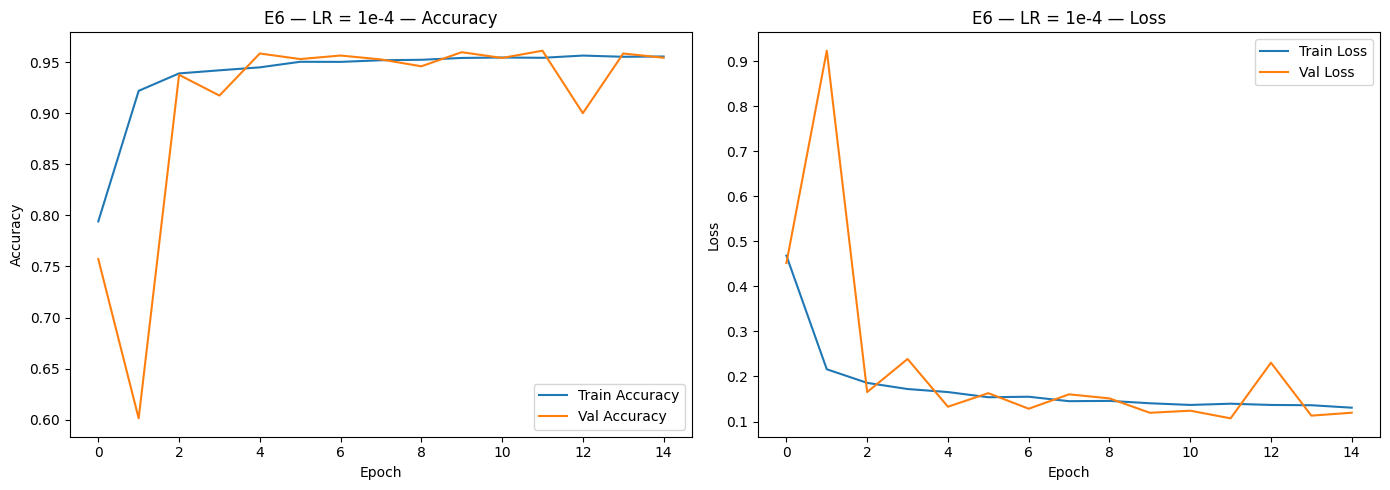

In [13]:
print("=" * 55)
print(" Experiment 6 — Learning Rate = 1e-4")
print("=" * 55)

adv_model_e6 = build_advanced_model(learning_rate=1e-4)

hist_adv6 = adv_model_e6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv6, title="E6 — LR = 1e-4")

### Experiment 7 — RMSprop Optimizer



 Experiment 7 — RMSprop Optimizer
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.6667 - loss: 0.9420 - val_accuracy: 0.8107 - val_loss: 0.4322
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.8959 - loss: 0.3332 - val_accuracy: 0.9209 - val_loss: 0.2829
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.9185 - loss: 0.2761 - val_accuracy: 0.9122 - val_loss: 0.2481
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.9252 - loss: 0.2788 - val_accuracy: 0.4988 - val_loss: 10.5866
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.9273 - loss: 0.2522 - val_accuracy: 0.9456 - val_loss: 0.1638
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.9262 - loss: 0.2537 - val_accuracy: 0.9414 - val_loss: 0.1609
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9277 - loss: 0.2534 - val_accuracy: 0.8568 - val_loss: 0.2888
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step -

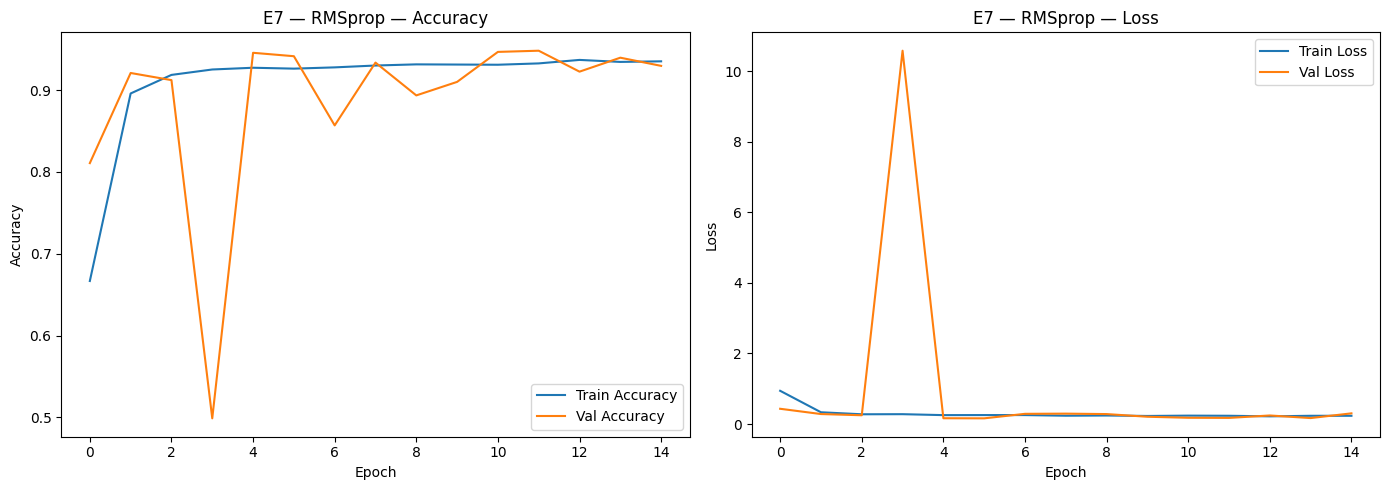

In [14]:
print("=" * 55)
print(" Experiment 7 — RMSprop Optimizer")
print("=" * 55)

adv_model_e7 = build_advanced_model(optimizer_name="rmsprop")

hist_adv7 = adv_model_e7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

plot_learning_curves(hist_adv7, title="E7 — RMSprop")

## 7. Consolidated Results Table

All seven experiments are evaluated on the validation set. Metrics reported are:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**

In [15]:
experiments = {
    "E1_Default_Augmented":  adv_model_e1,
    "E2_No_Augmentation":    adv_model_e2,
    "E3_2_ConvBlocks":       adv_model_e3,
    "E4_4_ConvBlocks":       adv_model_e4,
    "E5_Dropout_0.6":        adv_model_e5,
    "E6_LR_1e-4":            adv_model_e6,
    "E7_RMSprop":            adv_model_e7,
}

results = []
all_preds = {}   # store for later use in confusion matrix / ROC

for name, model in experiments.items():
    print(f"\nEvaluating {name}...")
    y_true, y_pred, y_scores = evaluate_model(model, val_ds)
    all_preds[name] = (y_true, y_pred, y_scores)
    results.append([
        name,
        round(accuracy_score(y_true, y_pred),  4),
        round(precision_score(y_true, y_pred), 4),
        round(recall_score(y_true, y_pred),    4),
        round(f1_score(y_true, y_pred),        4)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Experiment", "Accuracy", "Precision", "Recall", "F1-Score"]
)
results_df


Evaluating E1_Default_Augmented...
              precision    recall  f1-score   support

 Parasitized       0.98      0.93      0.95      2717
  Uninfected       0.93      0.98      0.96      2794

    accuracy                           0.96      5511
   macro avg       0.96      0.95      0.96      5511
weighted avg       0.96      0.96      0.96      5511


Evaluating E2_No_Augmentation...
              precision    recall  f1-score   support

 Parasitized       0.98      0.92      0.95      2717
  Uninfected       0.93      0.98      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.95      0.95      0.95      5511
weighted avg       0.95      0.95      0.95      5511


Evaluating E3_2_ConvBlocks...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

 Parasitized       0.49      1.00      0.66      2717
  Uninfected       0.00      0.00      0.00      2794

    accuracy                           0.49      5511
   macro avg       0.25      0.50      0.33      5511
weighted avg       0.24      0.49      0.33      5511


Evaluating E4_4_ConvBlocks...
              precision    recall  f1-score   support

 Parasitized       0.99      0.93      0.96      2717
  Uninfected       0.93      0.99      0.96      2794

    accuracy                           0.96      5511
   macro avg       0.96      0.96      0.96      5511
weighted avg       0.96      0.96      0.96      5511


Evaluating E5_Dropout_0.6...
              precision    recall  f1-score   support

 Parasitized       0.99      0.92      0.95      2717
  Uninfected       0.92      0.99      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.96      0.95      0.95      5511
weighted avg 

,Experiment,Accuracy,Precision,Recall,F1-Score
0,E1_Default_Augmented,0.9552,0.9313,0.9843,0.9570
1,E2_No_Augmentation,0.9501,0.9271,0.9785,0.9521
2,E3_2_ConvBlocks,0.4930,0.0000,0.0000,0.0000
3,E4_4_ConvBlocks,0.9588,0.9346,0.9878,0.9605
4,E5_Dropout_0.6,0.9526,0.9249,0.9868,0.9548
5,E6_LR_1e-4,0.9543,0.9303,0.9835,0.9562
6,E7_RMSprop,0.9296,0.9560,0.9026,0.9286


## 8. Best Model — Detailed Visualisations

After reviewing the results table above, the best-performing experiment is selected for detailed visual analysis. Update `BEST_EXPERIMENT` below to match whichever experiment had the highest F1-Score.

Visualising best experiment: E1_Default_Augmented



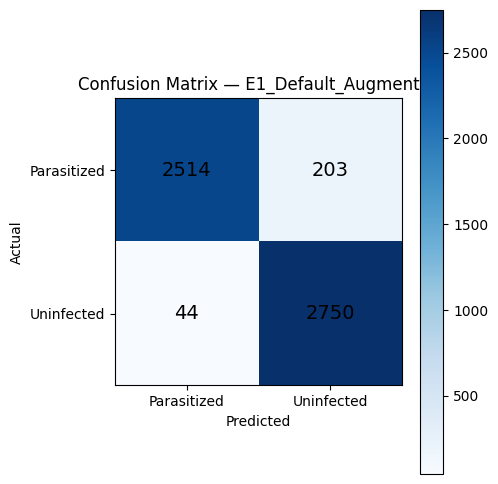

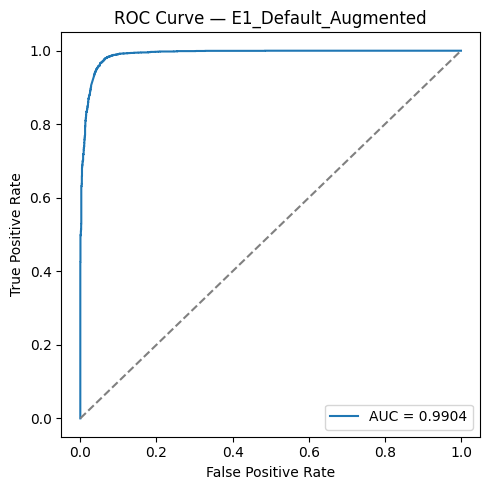

AUC: 0.9904


In [16]:
# ── Update this to the name of the best experiment after reviewing results_df ──
BEST_EXPERIMENT = "E1_Default_Augmented"   # <-- change if needed

y_true, y_pred, y_scores = all_preds[BEST_EXPERIMENT]

print(f"Visualising best experiment: {BEST_EXPERIMENT}\n")

# Confusion Matrix
plot_confusion_matrix(y_true, y_pred,
                      title=f"Confusion Matrix — {BEST_EXPERIMENT}")

# ROC / AUC Curve
best_auc = plot_roc_curve(y_true, y_scores,
                          title=f"ROC Curve — {BEST_EXPERIMENT}")

## 9. All-Experiment Learning Curves (Side-by-Side)

The grid below shows accuracy and loss curves for all 7 experiments, making it easy to compare convergence speed, stability, and overfitting patterns across configurations.

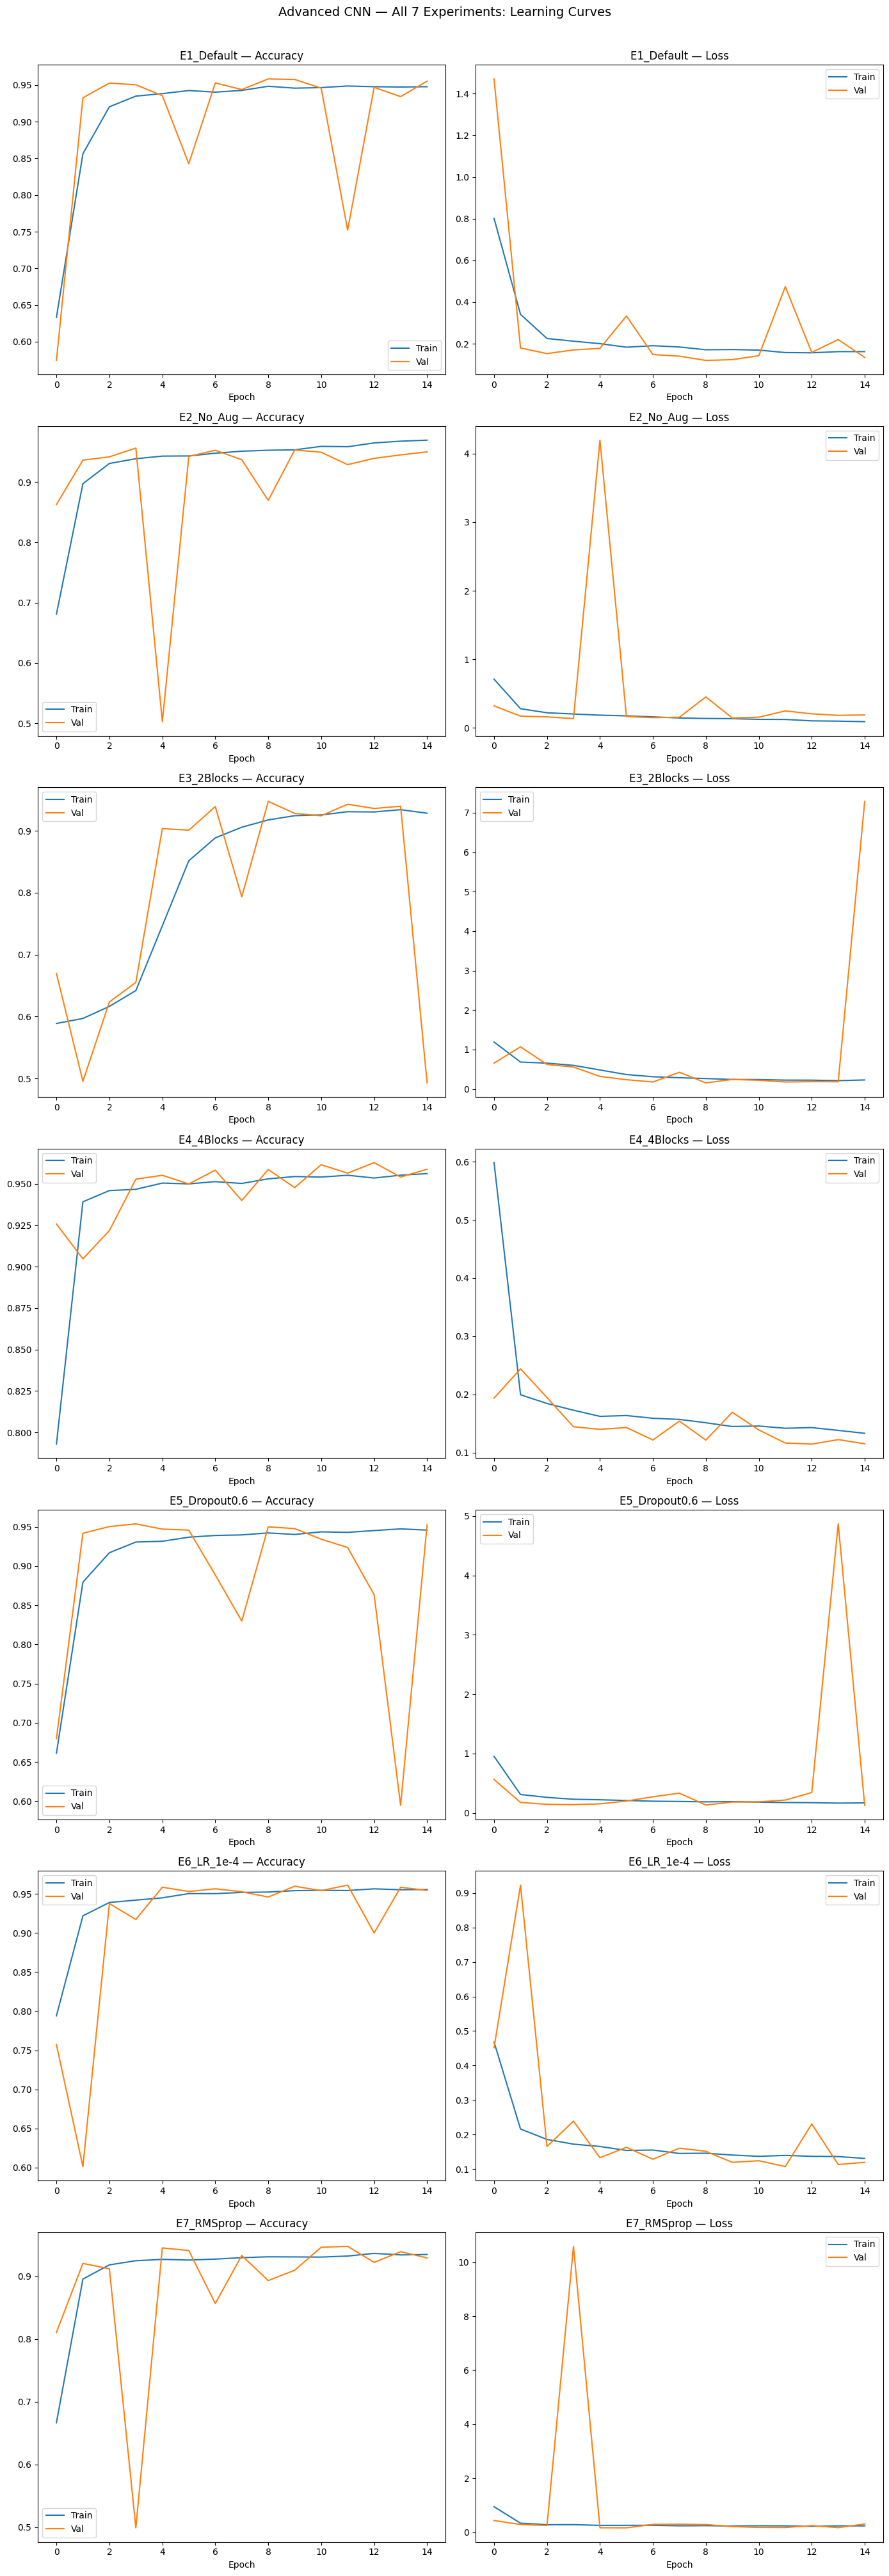

In [17]:
all_histories = {
    "E1_Default":        hist_adv1,
    "E2_No_Aug":         hist_adv2,
    "E3_2Blocks":        hist_adv3,
    "E4_4Blocks":        hist_adv4,
    "E5_Dropout0.6":     hist_adv5,
    "E6_LR_1e-4":        hist_adv6,
    "E7_RMSprop":        hist_adv7,
}

fig, axes = plt.subplots(7, 2, figsize=(14, 40))

for i, (name, hist) in enumerate(all_histories.items()):
    axes[i, 0].plot(hist.history['accuracy'],     label='Train')
    axes[i, 0].plot(hist.history['val_accuracy'], label='Val')
    axes[i, 0].set_title(f"{name} — Accuracy")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['loss'],     label='Train')
    axes[i, 1].plot(hist.history['val_loss'], label='Val')
    axes[i, 1].set_title(f"{name} — Loss")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].legend()

plt.suptitle("Advanced CNN — All 7 Experiments: Learning Curves",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

## 11. Results Discussion

Across seven experiments, E4 (4 Conv Blocks) achieved the best performance
with an accuracy of 0.9588 and F1-score of 0.9605, and was also the most
stable — both accuracy curves converged smoothly above 0.95 with no
significant loss spikes throughout training.

Augmentation proved beneficial: E1 outperformed E2 (F1: 0.9570 vs 0.9521),
and E2's learning curves showed a severe validation loss spike to 4.2 at
epoch 4, confirming that augmentation stabilises training. Reducing depth to
2 blocks (E3) caused complete model failure (F1: 0.0000), proving the third
convolutional block is essential. Higher dropout of 0.6 (E5) over-regularised
the model, causing a validation accuracy collapse at epoch 13. The lower
learning rate (E6) produced smooth convergence but negligible improvement,
while RMSprop (E7) was the least stable optimizer, recording a validation
loss spike exceeding 10.0 at epoch 3.

The confusion matrix for the best model recorded 203 false negatives out of
2,717 parasitized cases (recall: 0.9843), and the ROC curve achieved an AUC
of 0.9904, indicating strong discriminative ability. In a medical context,
minimising false negatives is critical as missed malaria cases carry the
greatest clinical risk. Overall, Model 2 outperforms the Baseline CNN (Model 1)
and is expected to rank second within the group behind the pretrained models.